In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
drugs = pd.read_csv('drugs.csv')
grants = pd.read_csv('grants.csv')
grant_opt = pd.read_csv('grant_opportunity_details.csv')

## How many drugs are approved per year

In [ ]:
drugs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1988 entries, 0 to 1987
Data columns (total 28 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   category                                     1988 non-null   object 
 1   medicine_name                                1988 non-null   object 
 2   therapeutic_area                             1703 non-null   object 
 3   common_name                                  1984 non-null   object 
 4   active_substance                             1987 non-null   object 
 5   product_number                               1988 non-null   int64  
 6   patient_safety                               1988 non-null   bool   
 7   authorisation_status                         1987 non-null   object 
 8   atc_code                                     1960 non-null   object 
 9   additional_monitoring                        1988 non-null   bool   
 10  

In [ ]:
date=drugs[['decision_date', 'first_published','medicine_name','therapeutic_area','common_name','marketing_authorisation_date']]

In [ ]:
date.head(5)

,decision_date,first_published,medicine_name,therapeutic_area,common_name,marketing_authorisation_date
0,2022-11-17,2018-07-25T13:58:00Z,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",brentuximab vedotin,2012-10-25
1,2023-03-10,2018-07-26T14:20:00Z,Nityr,Tyrosinemias,nitisinone,2018-07-26
2,2023-03-09,2022-10-12T16:13:00Z,Ebvallo,Lymphoproliferative Disorders,tabelecleucel,2022-12-16
3,2023-02-24,2021-11-12T16:30:00Z,Ronapreve,COVID-19 virus infection,"casirivimab, imdevimab",2021-11-12
4,2023-01-26,2018-06-07T11:59:00Z,Cosentyx,"Arthritis, Psoriatic; Psoriasis; Spondylitis...",secukinumab,2015-01-14


In [ ]:
date.groupby('common_name').value_counts()

common_name                                                                   decision_date  first_published       medicine_name            therapeutic_area                                                  marketing_authorisation_date
13c-urea                                                                      2000-07-05     2000-07-05T02:00:00Z  Pylori-Chek              Breath Tests;  Helicobacter Infections                            1998-06-15                      1
                                                                              2020-01-16     2017-03-03T02:00:00Z  Pylobactell              Breath Tests;  Helicobacter Infections                            1998-05-07                      1
                                                                              2023-01-30     2018-03-07T01:09:00Z  Helicobacter Test INFAI  Breath Tests;  Helicobacter Infections                            1997-08-14                      1
5-aminolevulinic acid hydrochloride                                           2022-03-22     2018-07-24T14:40:00Z  Ameluz                   Keratosis, Actinic;  Carcinoma, Basal Cell                        2011-12-13                      1
                                                                              2022-08-05     2018-07-19T10:00:00Z  Gliolan                  Glioma                                                            2007-09-07                      1
                                                                                                                                                                                                                                             ..
zoledronic acid                                                               2022-06-22     2017-09-11T11:30:00Z  Zoledronic acid Mylan    Fractures, Bone                                                   2012-08-23                      1
                                                                              2023-01-16     2017-03-23T01:00:00Z  Aclasta                  Osteoporosis;  Osteitis Deformans;  Osteoporosis, Postmenopausal  2005-04-15                      1
zonisamide                                                                    2022-07-14     2018-03-26T12:02:00Z  Zonisamide Mylan         Epilepsy                                                          2016-03-31                      1
                                                                              2023-02-15     2018-01-08T08:00:00Z  Zonegran                 Epilepsies, Partial                                               2005-03-10                      1
zoonotic influenza vaccine (h5n1) (surface antigen, inactivated, adjuvanted)  2022-09-30     2017-05-19T00:00:00Z  Aflunov                  Influenza, Human;  Immunization;  Disease Outbreaks               2010-11-28                      1
Name: count, Length: 1623, dtype: int64

In [ ]:
date['decision_date'] = pd.to_datetime(date['decision_date'], errors='coerce')
date['approval_year'] = date['decision_date'].dt.year
drugs_approved_per_year = date['approval_year'].value_counts().sort_index()
display(drugs_approved_per_year.tail(10))

,count
approval_year,
2014.0,31
2015.0,30
2016.0,33
2017.0,37
2018.0,54
2019.0,59
2020.0,100
2021.0,381
2022.0,794


In [ ]:
drugs.head(5)

,category,medicine_name,therapeutic_area,common_name,active_substance,product_number,patient_safety,authorisation_status,atc_code,additional_monitoring,...,marketing_authorisation_holder_company_name,pharmacotherapeutic_group,date_of_opinion,decision_date,revision_number,condition_indication,species,first_published,revision_date,url
0,human,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",brentuximab vedotin,brentuximab vedotin,2455,False,authorised,L01XC12,False,...,Takeda Pharma A/S,Antineoplastic agents,2012-07-19,2022-11-17,34.0,Hodgkin lymphomaAdcetris is indicated for adul...,NaN,2018-07-25T13:58:00Z,2023-03-13T11:52:00Z,https://www.ema.europa.eu/en/medicines/human/E...
1,human,Nityr,Tyrosinemias,nitisinone,nitisinone,4582,False,authorised,A16AX04,False,...,Cycle Pharmaceuticals (Europe) Ltd,"Other alimentary tract and metabolism products,",2018-05-31,2023-03-10,4.0,Treatment of adult and paediatric patients wit...,NaN,2018-07-26T14:20:00Z,2023-03-10T17:29:00Z,https://www.ema.europa.eu/en/medicines/human/E...
2,human,Ebvallo,Lymphoproliferative Disorders,tabelecleucel,tabelecleucel,4577,False,authorised,NaN,True,...,Pierre Fabre Medicament,NaN,2022-10-13,2023-03-09,2.0,Ebvallo is indicated as monotherapy for treatm...,NaN,2022-10-12T16:13:00Z,2023-03-10T13:40:00Z,https://www.ema.europa.eu/en/medicines/human/E...
3,human,Ronapreve,COVID-19 virus infection,"casirivimab, imdevimab","casirivimab, imdevimab",5814,False,authorised,J06BD,True,...,Roche Registration GmbH,"Immune sera and immunoglobulins,",2021-11-11,2023-02-24,3.0,Ronapreve is indicated for:Treatment of COVID-...,NaN,2021-11-12T16:30:00Z,2023-03-10T12:29:00Z,https://www.ema.europa.eu/en/medicines/human/E...
4,human,Cosentyx,"Arthritis, Psoriatic; Psoriasis; Spondylitis...",secukinumab,secukinumab,3729,False,authorised,L04AC10,False,...,Novartis Europharm Limited,Immunosuppressants,2014-11-20,2023-01-26,30.0,Plaque psoriasisCosentyx is indicated for the ...,NaN,2018-06-07T11:59:00Z,2023-03-09T18:53:00Z,https://www.ema.europa.eu/en/medicines/human/E...


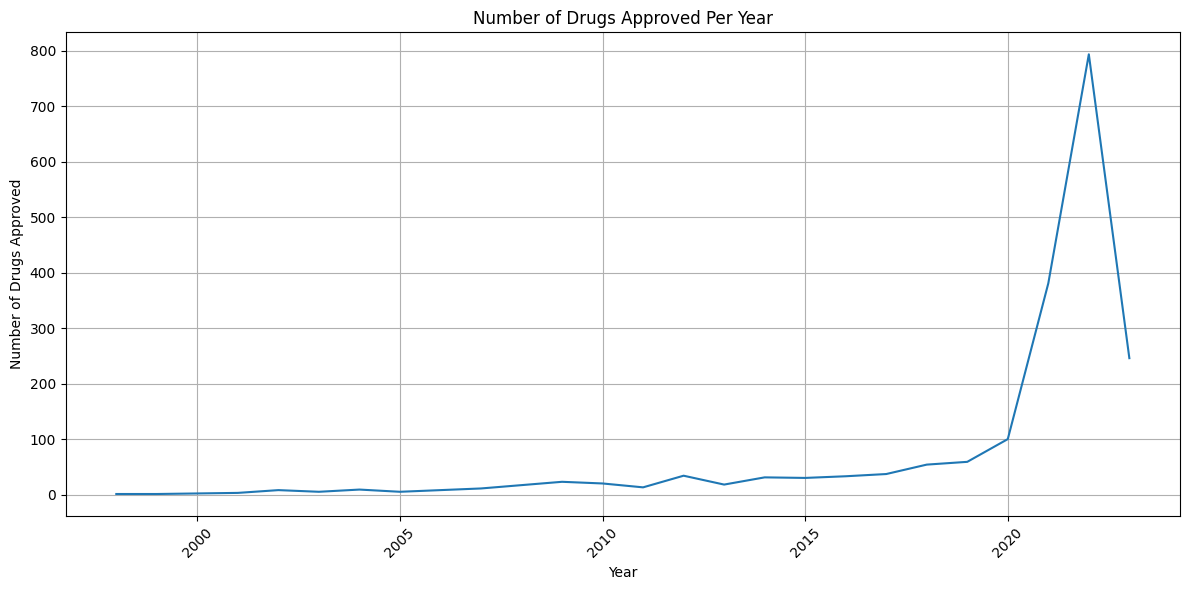

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=drugs_approved_per_year.index, y=drugs_approved_per_year.values)
plt.title('Number of Drugs Approved Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Drugs Approved')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Missingness data


<Figure size 1200x600 with 0 Axes>

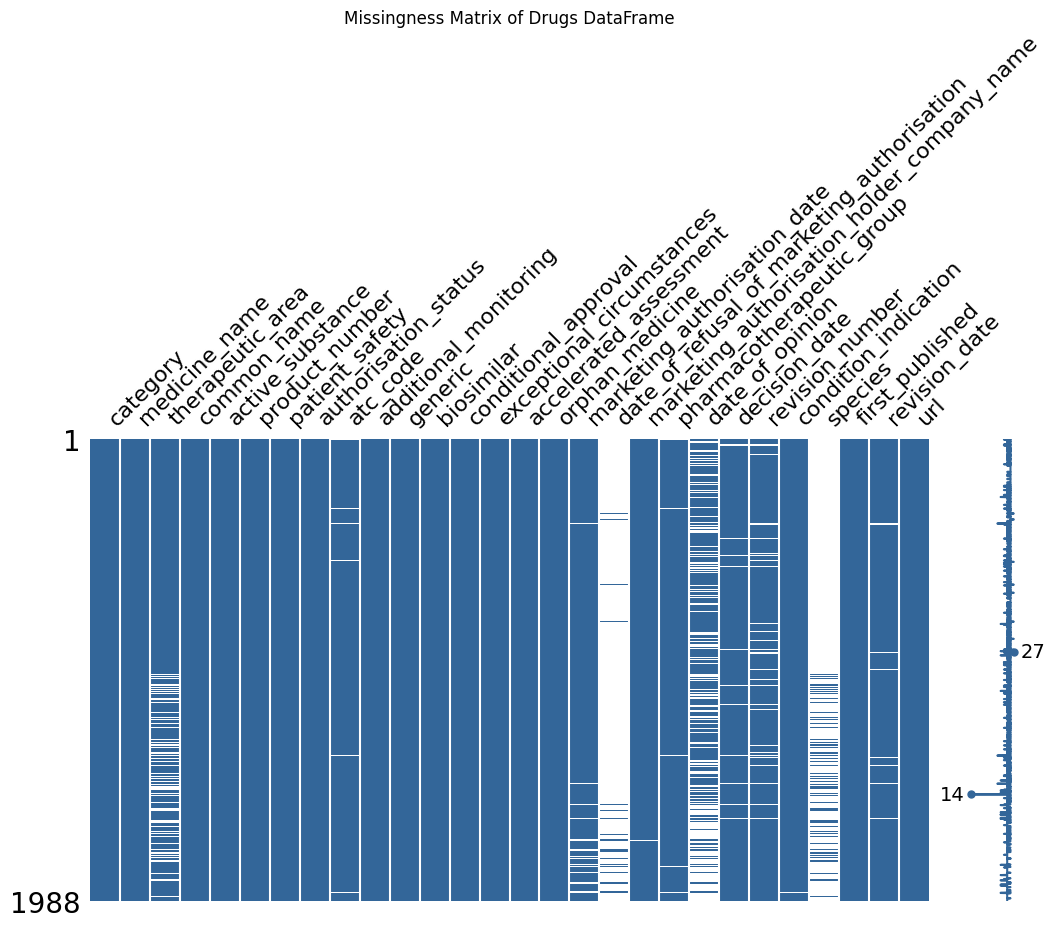

In [ ]:
import missingno as msno

plt.figure(figsize=(12, 6))
msno.matrix(drugs, figsize=(12, 6), color=(0.2, 0.4, 0.6))
plt.title('Missingness Matrix of Drugs DataFrame')
plt.show()

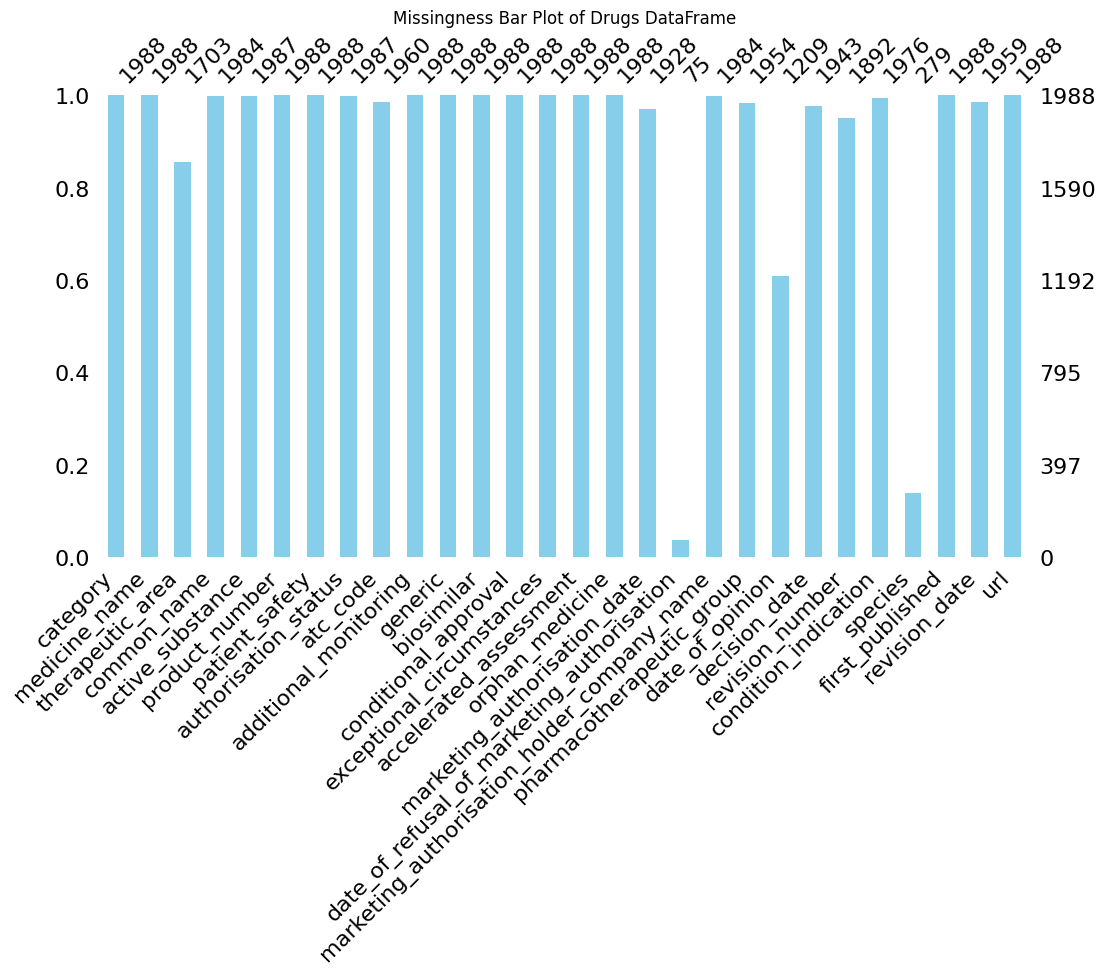

In [ ]:
plt.figure(figsize=(12, 6))
msno.bar(drugs, figsize=(12, 6), color='skyblue')
plt.title('Missingness Bar Plot of Drugs DataFrame')
plt.show()

## Grants

In [ ]:
grants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74669 entries, 0 to 74668
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   opportunity_id                  74669 non-null  int64  
 1   opportunity_number              74669 non-null  object 
 2   opportunity_title               74669 non-null  object 
 3   agency_code                     74626 non-null  object 
 4   agency_name                     74625 non-null  object 
 5   estimated_funding               53043 non-null  float64
 6   expected_number_of_awards       53371 non-null  object 
 7   grantor_contact                 74638 non-null  object 
 8   agency_contact_phone            668 non-null    object 
 9   agency_contact_email            73791 non-null  object 
 10  estimated_post_date             517 non-null    object 
 11  estimated_application_due_date  574 non-null    object 
 12  posted_date                     

In [ ]:
grants.head(5)

,opportunity_id,opportunity_number,opportunity_title,agency_code,agency_name,estimated_funding,expected_number_of_awards,grantor_contact,agency_contact_phone,agency_contact_email,estimated_post_date,estimated_application_due_date,posted_date,close_date,last_updated_date_time,version,opportunity_status
0,350373,EPA-R-OCSPP-OPPT-FY2023-001,Reducing Embodied Greenhouse Gas Emissions for...,EPA,Environmental Protection Agency,100000000.0,40.0,embodiedcarbon@epa.gov,NaN,embodiedcarbon@epa.gov,NaN,NaN,2023-09-28,2024-01-08,2023-09-28T09:47:28Z,Synopsis 1,Posted
1,350292,RD-RUS-CY22DISASTERCRTA,Calendar Year 2022 Disaster Circuit Rider Tech...,USDA-RUS,Rural Utilities Service,NaN,NaN,Penny Douglas\nGrantor\nPhone 202-253-0504,NaN,Water-RD@usda.gov,NaN,NaN,2023-09-28,2023-10-30,2023-09-28T09:58:28Z,Synopsis 8,Posted
2,350379,NOAA-OAR-SG-2025-23655,Fiscal Year 2025 National Sea Grant College Pr...,DOC-DOCNOAAERA,DOC NOAA - ERA Production,NaN,35.0,National Sea Grant College Program\nTel: (240)...,NaN,oar.sg.fellows@noaa.gov,NaN,NaN,2023-09-28,2024-02-15,2023-09-28T07:38:28Z,Synopsis 1,Posted
3,350340,CLIMATEANDTRANS,RESEARCH PARTNERSHIP ON CLIMATE CHANGE AND TRA...,DOT-RITA,69A355 Research and Technology,2500000.0,1.0,"Gretchen T. Goldman\nDirector, Climate Change ...",NaN,ClimateResearch@dot.gov,NaN,NaN,2023-09-28,2023-11-27,2023-09-28T09:56:28Z,Synopsis 2,Posted
4,350369,23-628,Mathematical and Physical Sciences Ascending F...,NSF,National Science Foundation,7500000.0,25.0,NSF grants.gov support\ngrantsgovsupport@nsf.gov,NaN,grantsgovsupport@nsf.gov,NaN,NaN,2023-09-28,NaN,2023-09-28T01:00:28Z,Synopsis 1,Posted


In [ ]:
grant_opt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 68 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   opportunity_id                                                       2000 non-null   int64  
 1   funding_opportunity_number                                           2000 non-null   object 
 2   funding_opportunity_title                                            2000 non-null   object 
 3   opportunity_category                                                 2000 non-null   object 
 4   opportunity_category_explanation                                     53 non-null     object 
 5   expected_number_of_awards                                            619 non-null    float64
 6   cost_sharing_or_matching_requirement                                 2000 non-null   bool   
 7   versio

In [ ]:
grant_opt.head(5)

,opportunity_id,funding_opportunity_number,funding_opportunity_title,opportunity_category,opportunity_category_explanation,expected_number_of_awards,cost_sharing_or_matching_requirement,version,posted_date,last_updated_date,...,category_income_security,category_info,category_law,category_natural_resources,category_opportunity_zone,category_regional_development,category_science,category_transportation,category_other,category_explanation
0,40112,DHS-FEMACAPSSSE-08-001,Community Assistance Program State Support Ser...,Discretionary,NaN,52.0,True,1,2007-11-28,2007-11-28,...,False,False,False,False,False,False,False,False,True,The purpose of the Community Assistance Progra...
1,40113,DHS-FEMACAPSSSE-08-001,Community Assistance Program State Support Ser...,Discretionary,NaN,52.0,True,1,2007-11-28,2007-11-28,...,False,False,False,False,False,False,False,False,True,The purpose of the Community Assistance Progra...
2,42048,FWS-R4-FLEXFUND,Southeast Region Flex Funds,Discretionary,NaN,25.0,False,3,2008-06-17,2008-06-18,...,False,False,False,True,False,False,False,False,False,NaN
3,42423,306-08-027-RFI,Alternative Development Program,Discretionary,NaN,1.0,False,1,2008-07-22,2008-07-22,...,False,False,False,False,False,False,False,False,False,NaN
4,45657,04-563,Developing Country Collaborations in Plant Gen...,Discretionary,NaN,NaN,True,2,2004-03-22,2009-03-03,...,False,False,False,False,False,False,True,False,False,NaN


In [ ]:
grants['posted_date'] = pd.to_datetime(grants['posted_date'], errors='coerce')
gr_annual = grants['posted_date'].dt.year.value_counts().sort_index()

display(gr_annual.head())

,count
posted_date,
2004,4
2005,10
2006,261
2007,350
2008,1958


,count
posted_date,
1,4897
2,6401
3,8153
4,7648
5,7981


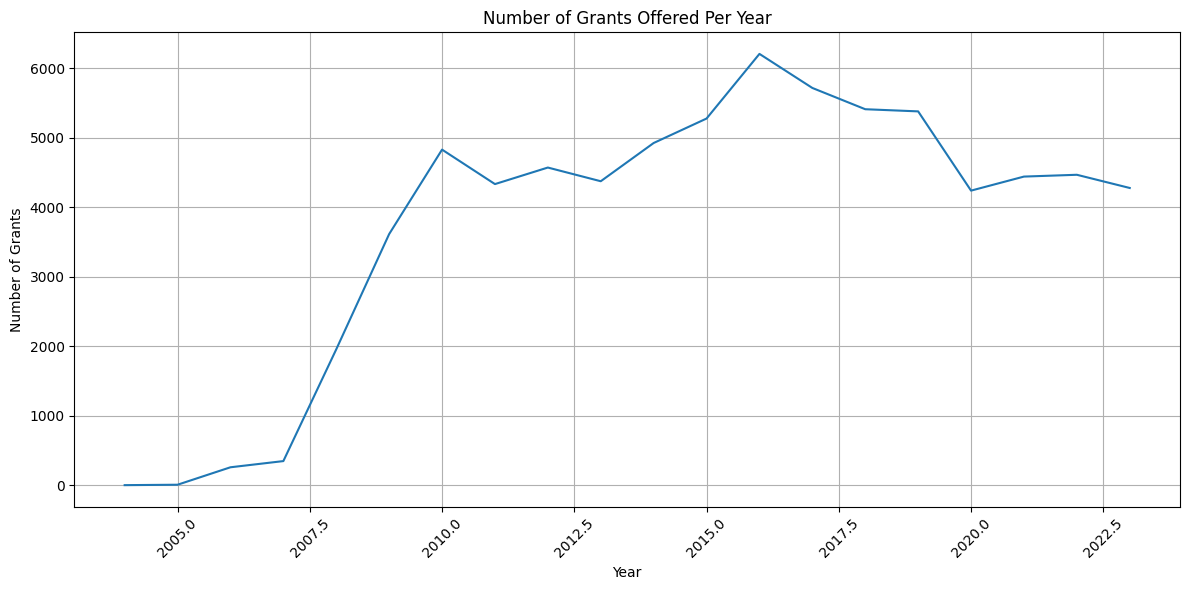

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=gr_annual.index, y=gr_annual.values)
plt.title('Number of Grants Offered Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Grants')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()